### HTCOM to ROMS
* This notebook is intended to interpolate HYCOM fields to ROMS grid and create an initial condition (IC) NetCDF for ROMS.

`version 1.0, MoeinDst, May-2026`

---
**<u>AI disclaimer</u>** -- Parts of the code and some functions were optimized by ChatGPT AI. Tests were carried out and once the logic was proven to be conceptually and physically correct/accurate, the code was optimized by AI agent.

---

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from datetime import datetime
import os, sys

import matplotlib.pyplot as plt
import cmocean

In [2]:
sys.path.append("/home/moein/pyroms/pyroms/")
import pyroms
sys.path.append("/home/moein/pyroms/pyroms_toolbox/")
sys.path.append("/home/moein/pyroms/pyroms_toolbox/pyroms_toolbox/")
import pyroms_toolbox

### Reading HYCOM fields

In [3]:
url = "https://tds.hycom.org/thredds/dodsC/GLBa0.08/expt_91.1/2015"
ds = xr.open_dataset(url, decode_times=True)

x_str=4020
x_end=4160
y_str=1280
y_end=1450

# period_start = datetime(2015,1,5)
# period_end = datetime(2015,4,5)
ic_time = datetime(2015, 1, 5)

ds_HYCOMmozambique = ds.sel(X=slice(x_str,x_end),
                            Y=slice(y_str,y_end),
                            MT=ic_time)

### Taking care of Longitude format
ds_HYCOMmozambique['Longitude'] = ((ds_HYCOMmozambique['Longitude'] + 180) % 360) -180

# print(ds_HYCOMmozambique)
# print(ds_HYCOMmozambique.data_vars)
# print(ds_HYCOMmozambique.coords)

##### Adjusting HYCOM to Mozambique Region
* Due to maximum depth for my domain, HYCOM subset contatin no value for the last two vertical levels (all NaNs). So, here I cut off the last two levels.

In [4]:
grd = '/home/moein/myROMS/general_notebooks/GridFiles/'\
            +'MozambiqueLv6_rxModifiedV6rx0_0.8v4.nc'
roms_grd = xr.open_dataset(grd)

print(np.nanmin(roms_grd["lon_rho"].values), np.nanmax(roms_grd["lon_rho"].values))
print(np.nanmin(roms_grd["lat_rho"].values), np.nanmax(roms_grd["lat_rho"].values))
print(np.nanmin(roms_grd["h"].values), np.nanmax(roms_grd["h"].values))
print(np.nanmin(roms_grd["mask_rho"].values), np.nanmax(roms_grd["mask_rho"].values))

39.266416848619485 46.0216520976241
-15.736993184371185 -6.513007400226575
5.000004600070894 4732.385633811088
0.0 1.0


In [5]:
print(
    f'HYCOM max. depth: {(ds_HYCOMmozambique["Depth"].max()).data}m,\
    ROMS max. depth: {(roms_grd["h"].max()).data}m'
    )

print(
    f'number of NaNs at 32th level: \
    {np.isnan(ds_HYCOMmozambique["temperature"][-2,:,:]).sum().values}'
    )
print(
    f'number of NaNs at 32th level: \
    {np.isnan(ds_HYCOMmozambique["temperature"][-1,:,:]).sum().values}'
    )
print(
    f'number of horizontal cells on HYCOM grid: \
    {ds_HYCOMmozambique["Y"].size * ds_HYCOMmozambique["X"].size}'
    )

HYCOM max. depth: 5500.0m,    ROMS max. depth: 4732.385633811088m
number of NaNs at 32th level:     24111
number of NaNs at 32th level:     24111
number of horizontal cells on HYCOM grid:     24111


In [6]:
ds_HYCOMmozambique = ds_HYCOMmozambique.isel(Depth=slice(0, -2))

---
### Interpolating horizontally

In [7]:
from scipy.interpolate import griddata

def horiz_interp_3d_hycom_to_roms(field, lon_src, lat_src, lon_dst, lat_dst, mask_dst=None):
    """
    Horizontally interpolate one HYCOM 3D field to ROMS rho points.

    Inputs are xarray DataArrays:
        field   : HYCOM field with dims (Depth, Y, X)
        lon_src : HYCOM Longitude with dims (Y, X)
        lat_src : HYCOM Latitude with dims (Y, X)
        lon_dst : ROMS lon_rho with dims (eta_rho, xi_rho)
        lat_dst : ROMS lat_rho with dims (eta_rho, xi_rho)
        mask_dst: ROMS mask_rho with dims (eta_rho, xi_rho)

    Output:
        xarray DataArray with dims (Depth, eta_rho, xi_rho)
        
    auth: moeindst, modified and optimized by ChatGPT AI.
    """

    # Keep dimension meaning explicit
    nz = field.sizes["Depth"]

    # Convert only internally for scipy/numpy operations
    lon_src_np = lon_src.to_numpy()
    lat_src_np = lat_src.to_numpy()
    lon_dst_np = lon_dst.to_numpy()
    lat_dst_np = lat_dst.to_numpy()

    if mask_dst is not None:
        mask_np = mask_dst.to_numpy()
    else:
        mask_np = None

    eta, xi = lon_dst_np.shape

    target = np.column_stack((
        lon_dst_np.ravel(),
        lat_dst_np.ravel()
    ))

    out = np.full((nz, eta, xi), np.nan)

    for k in range(nz):

        layer = field.isel(Depth=k).to_numpy()

        good = np.isfinite(layer)

        points_good = np.column_stack((
            lon_src_np[good],
            lat_src_np[good]
        ))

        values_good = layer[good]

        linear = griddata(
            points_good,
            values_good,
            target,
            method="linear"
        ).reshape(eta, xi)

        nearest = griddata(
            points_good,
            values_good,
            target,
            method="nearest"
        ).reshape(eta, xi)

        layer_roms = np.where(np.isnan(linear), nearest, linear)

        if mask_np is not None:
            layer_roms[mask_np == 0] = np.nan

        out[k, :, :] = layer_roms

        print(f"finished Depth level {k+1}/{nz}")

    return xr.DataArray(
        out,
        dims=("Depth", "eta_rho", "xi_rho"),
        coords={
            "Depth": field["Depth"].values,
            "lon_rho": (("eta_rho", "xi_rho"), lon_dst_np),
            "lat_rho": (("eta_rho", "xi_rho"), lat_dst_np),
        },
        name=field.name,
        attrs=field.attrs,
    )

In [ ]:
%%time

temp_hycom = ds_HYCOMmozambique["temperature"]
salt_hycom = ds_HYCOMmozambique["salinity"]

lon_hycom = ds_HYCOMmozambique["Longitude"]
lat_hycom = ds_HYCOMmozambique["Latitude"]

lon_roms = roms_grd["lon_rho"]
lat_roms = roms_grd["lat_rho"]
mask_roms = roms_grd["mask_rho"]

print("Working on Temperature interpolatin ...")
temp_horiz = horiz_interp_3d_hycom_to_roms(
    temp_hycom, lon_hycom, lat_hycom, lon_roms, lat_roms, mask_roms
)

print("Working on Salinity interpolatin ...")
salt_horiz = horiz_interp_3d_hycom_to_roms(
    salt_hycom, lon_hycom, lat_hycom, lon_roms, lat_roms, mask_roms
)

print(temp_horiz.shape)
print(salt_horiz.shape)

print(np.nanmin(temp_horiz), np.nanmax(temp_horiz))
print(np.nanmin(salt_horiz), np.nanmax(salt_horiz))


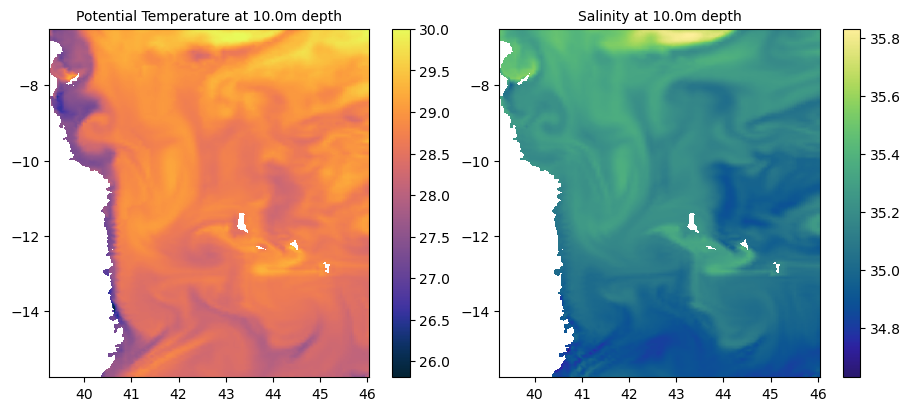

In [9]:
makeplot = True

if makeplot:
    fig,(ax_1,ax_2) = plt.subplots(1,2, figsize=(9,4),constrained_layout=True)

    depth_level = 1

    mappable1 = ax_1.pcolor(temp_horiz['lon_rho'],temp_horiz['lat_rho'],
                            temp_horiz[depth_level,:,:],cmap=cmocean.cm.thermal)
    cbar1 = plt.colorbar(mappable1,ax=ax_1)
    ax_1.set_title(f'Potential Temperature at {temp_horiz.Depth[depth_level].data}m depth', fontsize=10)

    mappable2 = ax_2.pcolor(salt_horiz['lon_rho'],salt_horiz['lat_rho'],
                            salt_horiz[depth_level,:,:],cmap=cmocean.cm.haline)
    cbar2 = plt.colorbar(mappable2, ax=ax_2)
    ax_2.set_title(f'Salinity at {salt_horiz.Depth[depth_level].data}m depth', fontsize=10)

### Interpolating vertically
Now we have HYCOM fields on the ROMS horizontal space, but still on HYCOM z-levels. So we first have to compute the corresponding ROMS z-levels from its relative vertical transformation scheme, and then interpolate from HYCOM z-levels to ROMS z-levels for each cell.

This part is gonna be computationally more effortful but rather simple. For this reason, it is better to leverage from the Dask and Chunks. However, there is an important caveat here. We should not do chunking in vertical space as the interpolation process needs the full vertical column. For this reason, the best option is to make chunks *<u>only</u>* in horizontal space.

In [10]:
def compute_zrho_vtransform2(grd):

    h = grd["h"]
    s_rho = grd["s_rho"]
    Cs_r = grd["Cs_r"]
    hc = float(grd["hc"])

    zeta = xr.zeros_like(h)

    S_rho = (hc * s_rho + h * Cs_r) / (hc + h)

    z_rho = zeta + (zeta + h) * S_rho

    z_rho = z_rho.transpose("s_rho", "eta_rho", "xi_rho") # ensuring correct order

    z_rho.name = "z_rho"

    z_rho.attrs["units"] = "meter"
    z_rho.attrs["positive"] = "up"

    return z_rho

### Loading raw IC file
* My workflow is that I create a so-called raw IC file from ROMS [matlab scripts](https://github.com/myroms/roms_matlab/tree/main/initial) (`d_initial.m`) written by Hernan Arango, ensuring full consistency with all necessary fields defined. Then I just pass values from calculations to the file and write it with ROMS compatible NetCDF.

In [11]:
raw_ic_Dir = '/home/moein/matlab_scripts/initial/generated/'
raw_ic = xr.open_dataset(os.path.join(raw_ic_Dir,"mozambique2015_ini_pchip.nc"))

* <u>Note</u>! In the below cell, it is better to load from `raw_ic`, as we're eventually writing the fileds into raw_ic. Using roms_grd is conceptually and physically correct, the only nuance is that there might be tiny mismatch between "s_rho" from the roms_grd and raw_ic to the insignificant digits!

In [12]:
# z_rho = compute_zrho_vtransform2(roms_grd)
z_rho = compute_zrho_vtransform2(raw_ic)

In [13]:
temp_horiz = temp_horiz.chunk({
    "Depth": -1,
    "eta_rho": temp_horiz['eta_rho'].size/4,
    "xi_rho": temp_horiz['xi_rho'].size/4,
})

salt_horiz = salt_horiz.chunk({
    "Depth": -1,
    "eta_rho": salt_horiz['eta_rho'].size/4,
    "xi_rho": salt_horiz['xi_rho'].size/4,
})

z_rho = z_rho.chunk({
    "s_rho": -1,
    "eta_rho": z_rho['eta_rho'].size/4,
    "xi_rho": z_rho['xi_rho'].size/4,
})

In [14]:
### xr.interp is very clean and straightforward, however it only works
### best for either 1D-column arrays or 1D-aware arrays. Here, when
### interpolating in vertical, I want it to be horizontally-aware, so
### I go for a np.interp inside xarray to leverage from both. This is
### fine as I am still benefiting from xr and dask and just jump to
### numpy for the interpolation part.

def interp_column_to_roms_depth(profile, depth_target, depth_source):
    """
    profile:       HYCOM values, shape (Depth,)
    depth_source:  HYCOM Depth, positive downward
    depth_target:  ROMS depth = -z_rho, to be positive downward
    
    auth: moeindst, modified and optimized by ChatGPT AI.
    """

    good = ~np.isnan(profile) & ~np.isnan(depth_source)

    if good.sum() < 2:
        return np.full(depth_target.shape, np.nan)

    depth_good = depth_source[good]
    profile_good = profile[good]

    order = np.argsort(depth_good)

    depth_good = depth_good[order]
    profile_good = profile_good[order]

    return np.interp(
        depth_target,
        depth_good,
        profile_good,
        left=profile_good[0],
        right=profile_good[-1],
    )

---
### Clustering to speed up procedure
Info on clustering with control on the number of workers and threads:

* 4 workers × 2 threads = 8 Dask threads

    4 workers × 8 GB = 32 GB Dask memory limit


* `free -h` for quick info on machine's memory and `lscpu` for cpu and threads information.

In [15]:
cluster_type = 'Local'
#cluster_type = 'Gateway'
#cluster_type = 'Coiled'

In [16]:
if cluster_type == 'Local':
    
    from dask.distributed import LocalCluster, Client

    cluster = LocalCluster(
        n_workers=3,
        threads_per_worker=2,
        memory_limit="10GB",
        processes=True,
        dashboard_address=":8282"
                            )

    client = Client(cluster)
    
### 4 workers × 2 threads = 8 Dask threads
### 4 workers × 8 GB = 32 GB Dask memory limit

In [17]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8282/status,
Dashboard: http://127.0.0.1:8282/status,Workers: 3
Total threads: 6,Total memory: 27.94 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41015,Workers: 3
Dashboard: http://127.0.0.1:8282/status,Total threads: 6
Started: Just now,Total memory: 27.94 GiB
Comm: tcp://127.0.0.1:43873,Total threads: 2
Dashboard: http://127.0.0.1:43639/status,Memory: 9.31 GiB
Nanny: tcp://127.0.0.1:44133,


#### Come back and run the cell below when finished!
* Make sure you close the cluster and free CPUs.

---

In [18]:
%%time

temp_roms = xr.apply_ufunc(
    interp_column_to_roms_depth,
    temp_horiz,
    -z_rho,
    temp_horiz["Depth"],
    input_core_dims=[["Depth"], ["s_rho"], ["Depth"]],
    output_core_dims=[["s_rho"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[temp_horiz.dtype],
    dask_gufunc_kwargs={
        "output_sizes": {"s_rho": z_rho.sizes["s_rho"]}
    },
)

temp_roms = temp_roms.transpose("s_rho", "eta_rho", "xi_rho")


salt_roms = xr.apply_ufunc(
    interp_column_to_roms_depth,
    salt_horiz,
    -z_rho,
    salt_horiz["Depth"],
    input_core_dims=[["Depth"], ["s_rho"], ["Depth"]],
    output_core_dims=[["s_rho"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[salt_horiz.dtype],
    dask_gufunc_kwargs={
        "output_sizes": {"s_rho": z_rho.sizes["s_rho"]}
    },
)
salt_roms = salt_roms.transpose("s_rho", "eta_rho", "xi_rho")

CPU times: user 13.9 ms, sys: 36 µs, total: 13.9 ms
Wall time: 13.6 ms


In [19]:
temp_roms

<xarray.DataArray (s_rho: 30, eta_rho: 1200, xi_rho: 588)>
dask.array<transpose, shape=(30, 1200, 588), dtype=float64, chunksize=(30, 300, 147), chunktype=numpy.ndarray>
Coordinates:
    lon_rho  (eta_rho, xi_rho) float64 dask.array<chunksize=(300, 147), meta=np.ndarray>
    lat_rho  (eta_rho, xi_rho) float64 dask.array<chunksize=(300, 147), meta=np.ndarray>
  * s_rho    (s_rho) float64 -0.9833 -0.95 -0.9167 ... -0.08333 -0.05 -0.01667
Dimensions without coordinates: eta_rho, xi_rho

### Writing the fields to the `raw_ic`

In [20]:
%%time
ic_new = raw_ic.copy(deep=True)

ic_new["temp"][0, :, :, :] = temp_roms.transpose("s_rho", "eta_rho", "xi_rho") #ensures dim-order
ic_new["salt"][0, :, :, :] = salt_roms.transpose("s_rho", "eta_rho", "xi_rho") #ensures dim-order

CPU times: user 984 ms, sys: 1.15 s, total: 2.14 s
Wall time: 11.1 s


#### Some diagnostics on the final result:

In [21]:
# %matplotlib notebook
%matplotlib inline

/tmp/ipykernel_14172/955842683.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mapp1 = ax_1.pcolormesh(x, z, temp_slice, shading="nearest",cmap=cmocean.cm.thermal)
/tmp/ipykernel_14172/955842683.py:15: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mapp2 = ax_2.pcolormesh(x, z, salt_slice, shading="nearest",cmap=cmocean.cm.haline)


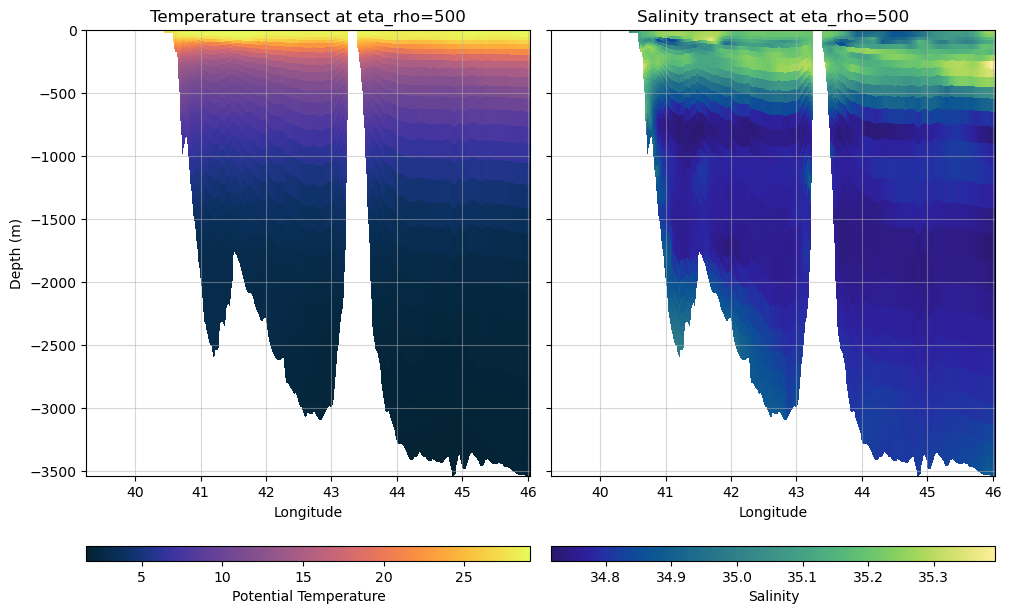

In [22]:
j = 500   # fixed eta index

x = ic_new['lon_rho'].isel(eta_rho=j)
y = ic_new['lat_rho'].isel(eta_rho=j)
z = z_rho.isel(eta_rho=j)
temp_slice = temp_roms.isel(eta_rho=j)
salt_slice = salt_roms.isel(eta_rho=j)

fig,(ax_1,ax_2) = plt.subplots(1,2,figsize=(10, 6),constrained_layout=True,sharey=True,sharex=True)
mapp1 = ax_1.pcolormesh(x, z, temp_slice, shading="nearest",cmap=cmocean.cm.thermal)
cbar1 = plt.colorbar(mapp1,label="Potential Temperature",location='bottom',ax=ax_1,aspect=30)
ax_1.set_ylabel("Depth (m)")
ax_1.set_title(f"Temperature transect at eta_rho={j}")

mapp2 = ax_2.pcolormesh(x, z, salt_slice, shading="nearest",cmap=cmocean.cm.haline)
cbar2 = plt.colorbar(mapp2,label="Salinity",location='bottom',ax=ax_2,aspect=30)
ax_2.set_title(f"Salinity transect at eta_rho={j}")

for ax in (ax_1,ax_2):
    ax.grid(alpha=0.5)
    ax.set_xlabel("Longitude")

* The warning is actually very important here.The *weirdness* seen in the sigma-coordinate plot is partly a plotting artifact and not necessarily instability. That is why `contourf` often give cleaner sigma-coordinate transects than `pcolormesh`.

In [23]:
### In order to plot using Contourf, I need the x in 2D, consistent with the z_rho shape
X2D = np.tile(x.to_numpy(), (z.sizes["s_rho"], 1))

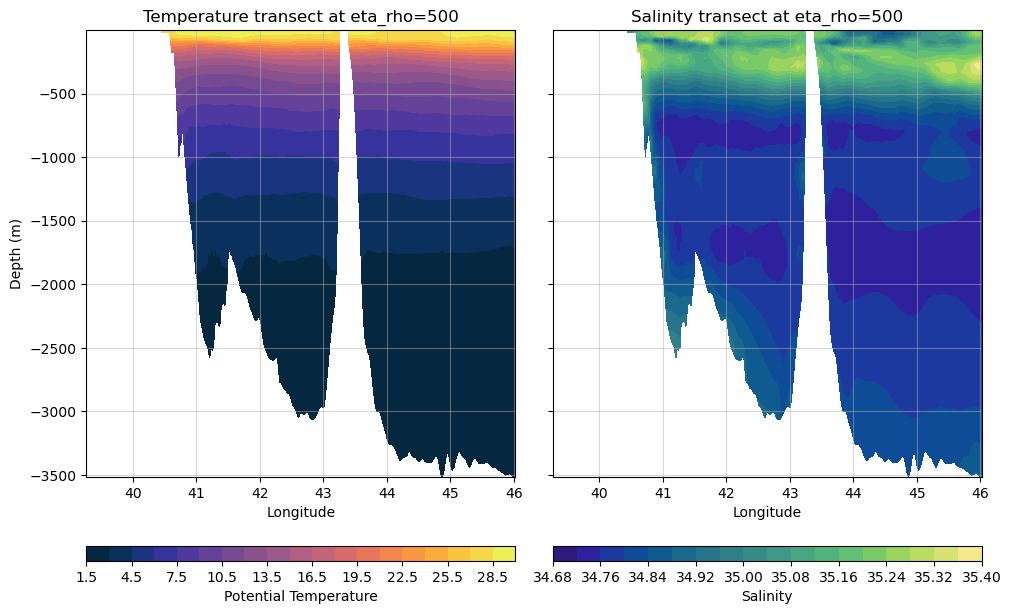

In [24]:
j = 500   # fixed eta index

x = ic_new['lon_rho'].isel(eta_rho=j)
y = ic_new['lat_rho'].isel(eta_rho=j)
z = z_rho.isel(eta_rho=j)
temp_slice = temp_roms.isel(eta_rho=j)
salt_slice = salt_roms.isel(eta_rho=j)
mylevs = 21

fig,(ax_1,ax_2) = plt.subplots(1,2,figsize=(10, 6),constrained_layout=True,sharey=True,sharex=True)
mapp1 = ax_1.contourf(X2D, z, temp_slice,cmap=cmocean.cm.thermal,levels=mylevs)
cbar1 = plt.colorbar(mapp1,label="Potential Temperature",location='bottom',ax=ax_1,aspect=30)
ax_1.set_ylabel("Depth (m)")
ax_1.set_title(f"Temperature transect at eta_rho={j}")

mapp2 = ax_2.contourf(X2D, z, salt_slice,cmap=cmocean.cm.haline,levels=mylevs)
cbar2 = plt.colorbar(mapp2,label="Salinity",location='bottom',ax=ax_2,aspect=30)
ax_2.set_title(f"Salinity transect at eta_rho={j}")

for ax in (ax_1,ax_2):
    ax.grid(alpha=0.5)
    ax.set_xlabel("Longitude")

* Importing density calculation from [pyroms](https://github.com/ESMG/pyroms/tree/python3):

In [25]:
sys.path.append('/home/moein/pyroms/pyroms_toolbox/pyroms_toolbox/seawater/')
import density

In [26]:
dens_roms = density.dens(ic_new['salt'],ic_new['temp'])

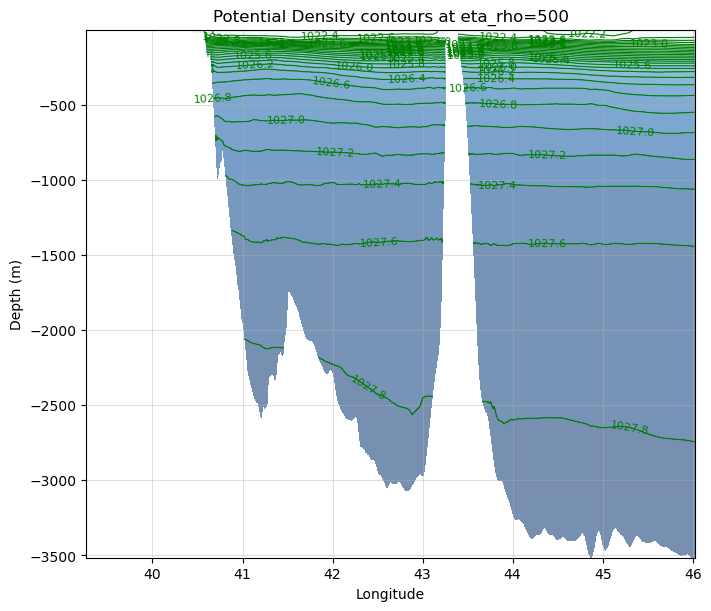

In [27]:
j = 500

x = ic_new["lon_rho"].isel(eta_rho=j).to_numpy()
z = z_rho.isel(eta_rho=j).to_numpy()

rho_sec = dens_roms.isel(ocean_time=0,eta_rho=j).to_numpy()

X2D = np.tile(x, (z.shape[0], 1))

# levels = np.arange(1022.2, 1027.9, 0.2)
levels = 30

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

cf = ax.contourf(
    X2D, z, rho_sec,
    levels=levels,
    cmap="Blues",
    alpha=0.55
)

cs = ax.contour(
    X2D, z, rho_sec,
    levels=levels,
    colors="g",
    linewidths=0.8
)

ax.clabel(cs, inline=False, fontsize=8, fmt="%.1f")

ax.set_title(f"Potential Density contours at eta_rho={j}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Depth (m)")
ax.grid(alpha=0.4)

In [ ]:
j = 500
i = 250

temp_profile = temp_horiz.isel(eta_rho=j, xi_rho=i).to_numpy()
salt_profile = salt_horiz.isel(eta_rho=j, xi_rho=i).to_numpy()
depth_source = temp_horiz["Depth"].to_numpy()
depth_target = (-z_rho.isel(eta_rho=j, xi_rho=i)).to_numpy()

print("profile shape:", temp_profile.shape)
print("depth_source shape:", depth_source.shape)
print("depth_target shape:", depth_target.shape)

print("profile:", temp_profile)
print("depth_source:", depth_source)
print("depth_target:", depth_target)

temp_col = interp_column_to_roms_depth(
    profile=temp_profile,
    depth_target=depth_target,
    depth_source=depth_source
)

salt_col = interp_column_to_roms_depth(
    profile=salt_profile,
    depth_target=depth_target,
    depth_source=depth_source
)

print("temp_col shape:", temp_col.shape)
print("temp_col:", temp_col)

In [ ]:
temp_roms.isel(s_rho=-1).max().values

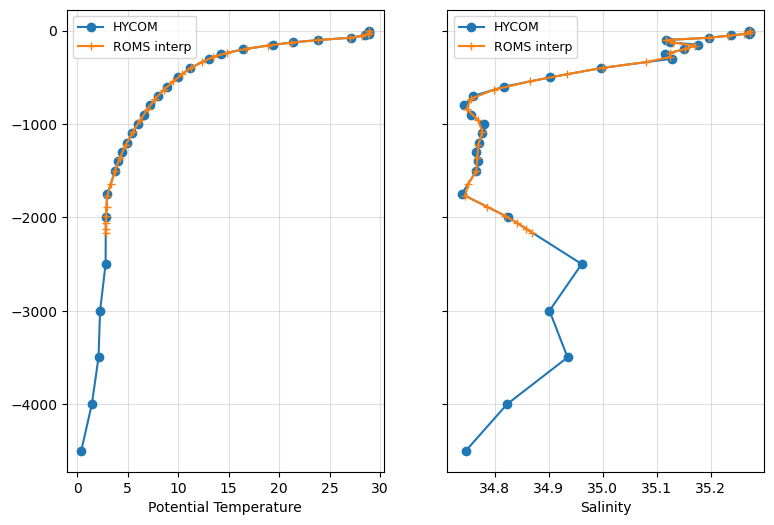

In [30]:
fig,(ax_1,ax_2) = plt.subplots(1,2,figsize=(9,6),sharey=True)

ax_1.plot(temp_profile, -depth_source, "o-", label="HYCOM")
ax_1.plot(temp_col, -depth_target, "+-", label="ROMS interp")
ax_1.set_xlabel('Potential Temperature', fontsize=10)

ax_2.plot(salt_profile, -depth_source, "o-", label="HYCOM")
ax_2.plot(salt_col, -depth_target, "+-", label="ROMS interp")
ax_2.set_xlabel('Salinity', fontsize=10)


for ax in (ax_1,ax_2):
    ax.legend(fontsize=9)
    ax.grid(alpha=0.4)

#### Saving the ic_new as netcdf

In [31]:
save_dir = "~/myROMS/mozambiqueData/initial_condition/"
save_name = "Mozambique_ini_HYCOM_RealisticTS_20150105"
ic_new.to_netcdf(
    f'{save_dir}{save_name}.nc',format="NETCDF4", mode="w", engine="h5netcdf"
                )

In [33]:
ds_ic = xr.open_dataset(os.path.join(save_dir,f'{save_name}.nc'))

In [34]:
ds_ic

<xarray.Dataset>
Dimensions:      (s_rho: 30, s_w: 31, eta_rho: 1200, xi_rho: 588, eta_u: 1200,
                  xi_u: 587, eta_v: 1199, xi_v: 588, ocean_time: 1)
Coordinates:
    lat_rho      (eta_rho, xi_rho) float64 ...
    lat_u        (eta_u, xi_u) float64 ...
    lat_v        (eta_v, xi_v) float64 ...
    lon_rho      (eta_rho, xi_rho) float64 ...
    lon_u        (eta_u, xi_u) float64 ...
    lon_v        (eta_v, xi_v) float64 ...
  * ocean_time   (ocean_time) datetime64[ns] 2015-01-05
  * s_rho        (s_rho) float64 -0.9833 -0.95 -0.9167 ... -0.05 -0.01667
  * s_w          (s_w) float64 -1.0 -0.9667 -0.9333 ... -0.06667 -0.03333 0.0
Dimensions without coordinates: eta_rho, xi_rho, eta_u, xi_u, eta_v, xi_v
Data variables: (12/17)
    Cs_r         (s_rho) float64 ...
    Cs_w         (s_w) float64 ...
    Tcline       float64 ...
    Vstretching  int32 ...
    Vtransform   int32 ...
    h            (eta_rho, xi_rho) float64 ...
    ...           ...
    theta_s      float64 ...
    u            (ocean_time, s_rho, eta_u, xi_u) float64 ...
    ubar         (ocean_time, eta_u, xi_u) float64 ...
    v            (ocean_time, s_rho, eta_v, xi_v) float64 ...
    vbar         (ocean_time, eta_v, xi_v) float64 ...
    zeta         (ocean_time, eta_rho, xi_rho) float64 ...
Attributes:
    type:     ROMS INITIAL file
    history:  Initial file using Matlab script: c_initial, Tuesday - February...

#### *** Remember to close the client and the cluster!

In [32]:
client.close()
cluster.close()

---

                        <-------------------- End of Document -------------------->